# ⚖️ Regulus — AI Governance Standards Lookup

**Describe an AI issue or system in plain language; Regulus returns the regulatory provisions that apply — across frameworks, each with a source citation, cited cross-framework references, and an optional grounded interpretation.**

Regulus is, in one line, **RAG + a knowledge network**: retrieval over *real* regulatory text, enriched by a *cited* cross-framework graph, optionally interpreted by an LLM. It is built for AI governance and model-risk work, where the question is rarely *"what text is similar?"* but *"**which requirement applies, how does it map across frameworks, and can you show me the source?**"*

It is built on the [Geometric Knowledge Network (GKN)](https://github.com/minw0607/geometric_knowledge_network).

### This notebook, step by step
1. **Setup** — imports.
2. **Configure** — choose the standards, the retriever, and describe the AI system under review.
3. **Launch** — build the system (corpus + knowledge graph + interpreter) and show basic info.
4. **Scenarios** — realistic observations/questions to test.
5. **Retrieve & answer** — applicable provisions, then a grounded, cited interpretation.
6. **Visualize** — the regulatory neighborhood of the issue.

> **Guardrail:** every provision is a real, cited unit of an official framework; cross-framework crosswalks are **curated and cited, never invented**; and the LLM **interprets — it does not author regulation**.

## 1. Setup

In [1]:
# Auto-reload edited modules; no kernel restart needed after code changes.
try:
    _ip = get_ipython(); _ip.run_line_magic('load_ext', 'autoreload'); _ip.run_line_magic('autoreload', '2')
except Exception:
    pass

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))   # make `regulus` importable

from regulus import demo
demo.ensure_gkn()   # use installed GKN, or the local sibling checkout

[setup] Using local GKN checkout at /Users/minwu/Documents/GenAI/geometric_knowledge_network/src


## 2. Configure the system

Set your choices below.

- **`STANDARDS`** — which frameworks to load (comment any out).
- **`RETRIEVER`** — `'auto'` (recommended) uses **embeddings** when your Azure/OpenAI keys are available (reused automatically from the GKN `.env`) and falls back to TF-IDF otherwise; force `'embedding'` or `'tfidf'`.
- **`TARGET_SYSTEM`** — a description of the AI system under review; the interpreter tailors its answer to it.

*Risk categories* are the seven NIST trustworthiness characteristics (valid & reliable, safe, secure & resilient, accountable & transparent, explainable, privacy-enhanced, fair) — applied automatically; to customize, edit `risk.py`.

*Retrieval quality note:* provisions are indexed as **provision-scoped units** (each with a framework/title header), not arbitrary character windows — this is what makes retrieval land on the right article. Section 3 measures it.

In [2]:
STANDARDS = [
    # Regulatory / governance layer
    'eu_ai_act',        # EU AI Act — 113 articles
    'nist_ai_rmf',      # NIST AI RMF 1.0 — 72 subcategories
    'nist_ai_600_1',    # NIST AI 600-1 (GenAI Profile) — 49 action groups
    'oecd_ai',          # OECD AI Principles — 10
    'iso_42001',        # ISO/IEC 42001 — clause structure (reference)
    # Threat / control layer (security)
    'mitre_atlas',      # MITRE ATLAS — 170 adversarial techniques + 35 mitigations
    'owasp_llm_top10',  # OWASP Top 10 for LLM (2025) — 10 risks w/ preventions
]

# 'auto' uses embeddings when Azure/OpenAI keys are available (reused from GKN),
# else TF-IDF. Force with 'embedding' or 'tfidf'.
RETRIEVER = 'embedding'

TARGET_SYSTEM = (
    'A generative-AI customer-service assistant for a retail bank. It answers customer '
    'questions about mortgages, savings, and credit cards by retrieving from internal '
    'product documentation, and is live to the public.'
)

## 3. Launch the system

`demo.launch()` loads the chosen standards into citable provisions, builds the cited cross-framework knowledge network, and wires up the interpreter (it reuses your GKN Azure/OpenAI credentials automatically).

`overview()` is the **app card**: what Regulus is, the retrieval and generation models in use, the regulatory data store it covers, the knowledge-network structure, and its input/output contract — including the reproducibility guarantee.

In [3]:
reg = demo.launch(standards=STANDARDS, retriever=RETRIEVER, target_system=TARGET_SYSTEM)
reg.overview()

[DONE] EU AI Act: 113 provisions.
[INFO] NIST AI RMF 1.0: live parse unavailable (pypdf is required to parse the NIST AI RMF PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI RMF 1.0: 72 provisions (snapshot).
[INFO] NIST AI 600-1 (GenAI Profile): live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI 600-1 (GenAI Profile): 49 provisions (snapshot).
[INFO] OECD AI Principles: live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] OECD AI Principles: 10 provisions (snapshot).
[DONE] ISO/IEC 42001:2023: 16 provisions (reference snapshot).
[DONE] MITRE ATLAS: 205 provisions.
[DONE] OWASP Top 10 for LLM (2025): 10 provisions (reference snapshot).
[DONE] Loaded 475 provisions from 7 framework(s).
[INFO] Retrieval index: skipping 18 non-substantive provision(s) (definitions/amendments/entry-into-force). Set REGULUS_FILTER_NON_SUBSTANTIVE=0 to kee

## Regulus — AI-governance standards lookup

**What it is.** Domain-specialized GraphRAG for AI governance. You describe an AI
system and a scenario; Regulus retrieves the applicable provisions across multiple
frameworks, links them through a **cited cross-framework knowledge network**, and
(optionally) has an LLM interpret them into a grounded, cited assessment.

**Models**
- *Retrieval / embeddings:* `text-embedding-3-small` (dense) over provision-scoped units.
- *Generation (interpretation):* `gpt-5-4-20260305-gs` at temperature 0.

**Regulatory data store (475 provisions across 7 frameworks (457 indexed for retrieval; 18 non-substantive provisions — definitions, amendments, entry-into-force — are excluded as noise))**
  - EU AI Act — 113 provisions
  - ISO/IEC 42001:2023 — 16 provisions
  - MITRE ATLAS — 205 provisions
  - NIST AI 600-1 (GenAI Profile) — 49 provisions
  - NIST AI RMF 1.0 — 72 provisions
  - OECD AI Principles — 10 provisions
  - OWASP Top 10 for LLM (2025) — 10 provisions

**Knowledge network (KN) structure**
- Nodes: `Framework` → `Provision` → `RiskCategory`.
- Edges: `CONTAINS` (framework→provision), `ADDRESSES` (provision→risk),
  `CROSSWALK` (provision↔provision across frameworks — **curated & cited, never
  LLM-invented**).
- Size: 475 provisions · 400 crosswalk edges ·
  7 risk categories.

**Input** — a plain-language scenario/observation (e.g. *"our credit model was
deployed without testing for demographic bias"*), plus an optional description of
the system under review.

**Output** — a structured assessment: (1) the **risks**, (2) the **applicable
provisions** (primary + cited related provisions in other frameworks), and
(3) an **interpretation with recommended mitigants**, each grounded in a cited
provision.

**Reproducibility** — the risks and provisions are computed by code from a single
retrieval pass over a fixed data store, so the same scenario yields the **same
core** every run. Only the LLM's wording (section 3) may vary; it is labeled and
runs at temperature 0.


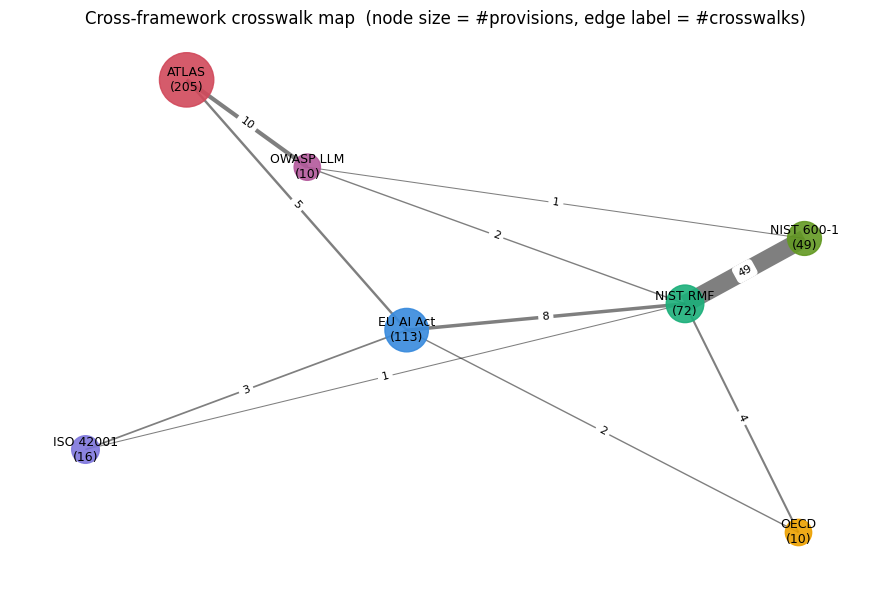

In [4]:
# The knowledge network at a glance: frameworks linked by the number of cited crosswalks.
_ = reg.framework_map()   # needs matplotlib

### Retrieval quality (does it find the right provision?)

A small labelled `issue → expected-provisions` set measures the data store — `hit` (any expected provision retrieved), `recall@k`, and `MRR`. This is how we tell whether a change to chunking or embeddings actually helps, rather than guessing. (Extend `regulus/eval.py` as coverage grows.)

In [5]:
# Retrieval quality on a small labelled eval set (hit-rate / recall@k / MRR).
demo.retrieval_report(reg, top_k=5)

,issue,hit,recall@k,mrr,top-1
0,Real-time facial recognition in public spaces ...,1.000,1.000,1.000,"EU AI Act, Article 5 — Prohibited AI practices"
1,Our credit model was deployed without testing ...,0.000,0.000,0.000,"NIST AI 600-1 (GenAI Profile), MS-2.11 — MEASU..."
2,No post-deployment monitoring of a high-risk A...,1.000,0.500,1.000,"EU AI Act, Article 72 — Post-market monitoring..."
3,Users are not told they are interacting with a...,1.000,1.000,1.000,"EU AI Act, Article 50 — Transparency obligatio..."
4,No human oversight of the model's automated de...,1.000,1.000,1.000,"EU AI Act, Article 14 — Human oversight"
5,The high-risk system was not validated for acc...,1.000,1.000,1.000,"EU AI Act, Article 15 — Accuracy, robustness a..."
6,No logging or records of the AI system's opera...,1.000,1.000,0.500,"MITRE ATLAS, AML.M0024 — AI Telemetry Logging"
7,There is no risk management system for our hig...,1.000,1.000,1.000,"EU AI Act, Article 9 — Risk management system"
8,We provide no instructions for use or transpar...,1.000,1.000,1.000,"EU AI Act, Article 13 — Transparency and provi..."
9,No fundamental rights impact assessment was pe...,1.000,1.000,1.000,"EU AI Act, Article 27 — Fundamental rights imp..."


## 4. Test scenarios

Categorized hypothetical scenarios, one per governance theme — including security and agentic themes that exercise the **threat layer** (MITRE ATLAS techniques & mitigations, OWASP LLM Top 10). For those, the knowledge network can now chain **regulation → threat technique → concrete mitigation**, and every hop carries the *signal* (relation + rationale + provenance) explaining why the two documents are linked.

In [6]:
# A categorized set of hypothetical scenarios (one per governance theme) lives in
# the module, so it's reusable and testable. Pick one to walk through.
from regulus import demo

for name in demo.SCENARIOS:
    print("\u2022", name)

scenario = demo.SCENARIOS['Security \u2014 adversarial & prompt injection']
print("\n" + scenario)

• Prohibited use — biometric surveillance
• Bias — credit underwriting
• Transparency — undisclosed chatbot
• Human oversight — automated decisions
• Safety & robustness — unvalidated high-risk system
• Security — adversarial & prompt injection
• Privacy — personal data governance
• Record-keeping — no logging
• Risk management — no process
• Post-market monitoring — none
• Documentation & rights impact
• GenAI — hallucination & provenance
• Agentic — autonomous tool use

Our public LLM assistant has no defences against prompt injection or data-poisoning, and we have done no adversarial or cybersecurity testing of the model or its data pipeline.


## 5. Assess a scenario

`reg.assess(scenario)` produces the full, **reproducible** assessment, now organized as tables:

1. **Risks, standards & controls** \u2014 each risk, the provisions (standards) that govern it, and a suggested control/mitigant (a curated, deterministic control library \u2014 *pre-built rules*, not LLM output).
2. **Priority (graph leverage)** \u2014 which provision to address *first*. This is the knowledge-network insight (see \u00a76).
3. **Cross-framework reach** \u2014 provisions the graph surfaces by following crosswalks, that similarity retrieval alone missed.
4. **Interpretation & recommended mitigants** \u2014 the LLM narrates *why* and adds scenario-specific mitigants, each grounded in a cited provision.

Pass `export=True` to save the report to `artifacts/assessments/` as Markdown + JSON + CSV (deterministic core \u2192 byte-identical across runs; only \u00a74's wording can vary).

In [7]:
# Full assessment (rendered) + saved to artifacts/assessments/
assessment = reg.assess(scenario, export=True)

## Regulus assessment
**System under review:** A generative-AI customer-service assistant for a retail bank. It answers customer questions about mortgages, savings, and credit cards by retrieving from internal product documentation, and is live to the public.
**Scenario:** Our public LLM assistant has no defences against prompt injection or data-poisoning, and we have done no adversarial or cybersecurity testing of the model or its data pipeline.

### 1. Risks, standards & controls
| risk | relevant provisions (standards) | suggested control / mitigant |
| --- | --- | --- |
| Secure and resilient | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning \| OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection \| OWASP Top 10 for LLM (2025), LLM03 — Supply Chain \| OWASP Top 10 for LLM (2025), LLM05 — Improper Output Handling \| OWASP Top 10 for LLM (2025), LLM07 — System Prompt Leakage | Protect the system against adversarial attack and unexpected conditions, and recover gracefully. |
| Valid and reliable | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning \| OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection \| OWASP Top 10 for LLM (2025), LLM03 — Supply Chain \| OWASP Top 10 for LLM (2025), LLM05 — Improper Output Handling | Establish that the system performs accurately and reliably for its intended use before and after deployment. |
| Accountable and transparent | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain \| OWASP Top 10 for LLM (2025), LLM05 — Improper Output Handling | Make information and responsibility available across the lifecycle, with records that support audit. |
| Fair — with harmful bias managed | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning | Address equality/equity concerns and manage harmful bias across groups. |
| Safe | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection | Ensure the system does not lead to unacceptable harm under defined conditions of use. |

### 2. Priority — what to address first (graph leverage)
**Linchpin: OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection.** Highest leverage — relevant *and* the most connected provision in this scenario: it links 6 framework(s) (EU AI Act, MITRE ATLAS, NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0, OECD AI Principles, OWASP Top 10 for LLM (2025)) and shares risks with 4 other finding(s). Addressing it advances the most of the rest.

| rank | provision | relevance | frameworks linked | findings connected | leverage | priority score |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection | 0.613 | 6 | 4 | 9 | 6.2501 |
| 2 | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning | 0.633 | 3 | 4 | 6 | 4.5348 |
| 3 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain | 0.601 | 3 | 4 | 6 | 4.3067 |
| 4 | OWASP Top 10 for LLM (2025), LLM07 — System Prompt Leakage | 0.558 | 2 | 4 | 5 | 3.4181 |
| 5 | OWASP Top 10 for LLM (2025), LLM05 — Improper Output Handling | 0.573 | 1 | 4 | 4 | 2.9472 |

### 3. Cross-framework reach (via the knowledge graph)
Related provisions the graph surfaces by following cited crosswalks — the *same concern in other frameworks*, which similarity retrieval alone did not return:

| provision (via graph) | framework | hops | path | why linked (signal) |
| --- | --- | --- | --- | --- |
| MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise | MITRE ATLAS | 1 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain → MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise | related: LLM supply-chain risk (models, data, plugins, platforms) corresponds to ATLAS AI Supply Chain Compromise. |
| MITRE ATLAS, AML.T0020 — Poison Training Data | MITRE ATLAS | 1 | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning → MITRE ATLAS, AML.T0020 — Poison Training Data | related: Data and model poisoning during pre-training/fine-tuning/embedding is ATLAS's Poison Training Data technique. |
| MITRE ATLAS, AML.T0051 — LLM Prompt Injection | MITRE ATLAS | 1 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection | equivalent: Both describe the same attack: user or external content alters LLM behavior (direct/indirect prompt injection). |
| MITRE ATLAS, AML.T0054 — LLM Jailbreak | MITRE ATLAS | 1 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0054 — LLM Jailbreak | related: OWASP LLM01 explicitly treats jailbreaking as a form of prompt injection; ATLAS models it as its own technique. |
| MITRE ATLAS, AML.T0056 — Extract LLM System Prompt | MITRE ATLAS | 1 | OWASP Top 10 for LLM (2025), LLM07 — System Prompt Leakage → MITRE ATLAS, AML.T0056 — Extract LLM System Prompt | related: System prompt leakage corresponds to ATLAS's Extract LLM System Prompt technique. |
| NIST AI RMF 1.0, MEASURE 2.7 — Measure function | NIST AI RMF 1.0 | 1 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → NIST AI RMF 1.0, MEASURE 2.7 — Measure function | related: Prompt-injection resilience is part of measuring AI system security and resilience. |
| EU AI Act, Article 15 — Accuracy, robustness and cybersecurity | EU AI Act | 2 | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning → MITRE ATLAS, AML.T0020 — Poison Training Data → EU AI Act, Article 15 — Accuracy, robustness and cybersecurity | related: Article 15(5) requires high-risk systems to be resilient against attacks that 'manipulate the training data set (data poisoning)' and 'pre-trained components (model poisoning)' — the attacks this technique performs. |
| EU AI Act, Article 25 — Responsibilities along the AI value chain | EU AI Act | 2 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain → MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise → EU AI Act, Article 25 — Responsibilities along the AI value chain | related: Compromise of third-party AI components implicates the value-chain responsibilities that Article 25 allocates across providers. |
| MITRE ATLAS, AML.M0001 — Limit Model Artifact Release | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning → MITRE ATLAS, AML.T0020 — Poison Training Data → MITRE ATLAS, AML.M0001 — Limit Model Artifact Release | mitigates: Published datasets can be a target for poisoning attacks. |
| MITRE ATLAS, AML.M0005 — Control Access to AI Models and Data at Rest | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning → MITRE ATLAS, AML.T0020 — Poison Training Data → MITRE ATLAS, AML.M0005 — Control Access to AI Models and Data at Rest | mitigates: Access controls can prevent tampering with ML artifacts and prevent unauthorized copying. |
| MITRE ATLAS, AML.M0007 — Sanitize Training Data | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning → MITRE ATLAS, AML.T0020 — Poison Training Data → MITRE ATLAS, AML.M0007 — Sanitize Training Data | mitigates: Detect modification of data and labels which may cause adversarial model drift or backdoor attacks. |
| MITRE ATLAS, AML.M0008 — Validate AI Model | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning → MITRE ATLAS, AML.T0020 — Poison Training Data → MITRE ATLAS, AML.M0008 — Validate AI Model | mitigates: Robust evaluation of an AI model can help increase confidence that the model has not been poisoned. |
| MITRE ATLAS, AML.M0014 — Verify AI Artifacts | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain → MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise → MITRE ATLAS, AML.M0014 — Verify AI Artifacts | mitigates: Introduce proper checking of signatures to ensure that unsafe AI artifacts will not be introduced to the system. |
| MITRE ATLAS, AML.M0019 — Control Access to AI Models and Data in Production | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection → MITRE ATLAS, AML.M0019 — Control Access to AI Models and Data in Production | mitigates: Use access controls in production to prevent adversaries from injecting malicious prompts. |
| MITRE ATLAS, AML.M0020 — Generative AI Guardrails | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection → MITRE ATLAS, AML.M0020 — Generative AI Guardrails | mitigates: Guardrails can prevent harmful inputs that can lead to prompt injection. |
| MITRE ATLAS, AML.M0021 — Generative AI Guidelines | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection → MITRE ATLAS, AML.M0021 — Generative AI Guidelines | mitigates: Model guidelines can instruct the model to refuse a response to unsafe inputs. |
| MITRE ATLAS, AML.M0022 — Generative AI Model Alignment | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection → MITRE ATLAS, AML.M0022 — Generative AI Model Alignment | mitigates: Model alignment can improve the parametric safety of a model by guiding it away from unsafe prompts and responses. |
| MITRE ATLAS, AML.M0023 — AI Bill of Materials | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning → MITRE ATLAS, AML.T0020 — Poison Training Data → MITRE ATLAS, AML.M0023 — AI Bill of Materials | mitigates: An AI BOM can help users identify untrustworthy model artifacts. |
| MITRE ATLAS, AML.M0024 — AI Telemetry Logging | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection → MITRE ATLAS, AML.M0024 — AI Telemetry Logging | mitigates: Telemetry logging can help identify if unsafe prompts have been submitted to the LLM. |
| MITRE ATLAS, AML.M0025 — Maintain AI Dataset Provenance | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning → MITRE ATLAS, AML.T0020 — Poison Training Data → MITRE ATLAS, AML.M0025 — Maintain AI Dataset Provenance | mitigates: Dataset provenance can protect against poisoning of training data |
| MITRE ATLAS, AML.M0033 — Input and Output Validation for AI Agent Components | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection → MITRE ATLAS, AML.M0033 — Input and Output Validation for AI Agent Components | mitigates: Validation can prevent adversaries from executing prompt injections that could affect agentic workflows. |
| MITRE ATLAS, AML.T0010.000 — Hardware | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain → MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise → MITRE ATLAS, AML.T0010.000 — Hardware | specializes: Hardware is an ATLAS sub-technique of AML.T0010. |
| MITRE ATLAS, AML.T0010.001 — AI Software | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain → MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise → MITRE ATLAS, AML.T0010.001 — AI Software | specializes: AI Software is an ATLAS sub-technique of AML.T0010. |
| MITRE ATLAS, AML.T0010.002 — Data | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain → MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise → MITRE ATLAS, AML.T0010.002 — Data | specializes: Data is an ATLAS sub-technique of AML.T0010. |
| MITRE ATLAS, AML.T0010.003 — Model | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain → MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise → MITRE ATLAS, AML.T0010.003 — Model | specializes: Model is an ATLAS sub-technique of AML.T0010. |
| MITRE ATLAS, AML.T0010.004 — Container Registry | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain → MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise → MITRE ATLAS, AML.T0010.004 — Container Registry | specializes: Container Registry is an ATLAS sub-technique of AML.T0010. |
| MITRE ATLAS, AML.T0010.005 — AI Agent Tool | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM03 — Supply Chain → MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise → MITRE ATLAS, AML.T0010.005 — AI Agent Tool | specializes: AI Agent Tool is an ATLAS sub-technique of AML.T0010. |
| MITRE ATLAS, AML.T0051.000 — Direct | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection → MITRE ATLAS, AML.T0051.000 — Direct | specializes: Direct is an ATLAS sub-technique of AML.T0051. |
| MITRE ATLAS, AML.T0051.001 — Indirect | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection → MITRE ATLAS, AML.T0051.001 — Indirect | specializes: Indirect is an ATLAS sub-technique of AML.T0051. |
| MITRE ATLAS, AML.T0051.002 — Triggered | MITRE ATLAS | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → MITRE ATLAS, AML.T0051 — LLM Prompt Injection → MITRE ATLAS, AML.T0051.002 — Triggered | specializes: Triggered is an ATLAS sub-technique of AML.T0051. |
| NIST AI 600-1 (GenAI Profile), MS-2.7 — MEASURE 2.7 — generative-AI suggested actions | NIST AI 600-1 (GenAI Profile) | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → NIST AI RMF 1.0, MEASURE 2.7 — Measure function → NIST AI 600-1 (GenAI Profile), MS-2.7 — MEASURE 2.7 — generative-AI suggested actions | supports: GenAI-specific suggested actions for AI RMF subcategory MEASURE 2.7. |
| OECD AI Principles, Principle 1.4 — Robustness, security and safety | OECD AI Principles | 2 | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection → NIST AI RMF 1.0, MEASURE 2.7 — Measure function → OECD AI Principles, Principle 1.4 — Robustness, security and safety | related: Robustness/security principle corresponds to security & resilience measurement. |

### 4. Interpretation & recommended mitigants
_Generated by gpt-5-4-20260305-gs at temperature 0 (labeled, best-effort reproducible) over the exact provisions above._

## 1. Why these provisions apply

- **OWASP LLM01 — Prompt Injection** applies because the assistant is a **public-facing generative AI system** that retrieves and responds to user inputs, and your observation explicitly says it has **no defences against prompt injection** and **no adversarial or cybersecurity testing**; OWASP specifically calls for adversarial testing, penetration testing, and breach simulations for prompt-injection risk [OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection].
- **OWASP LLM04 — Data and Model Poisoning** applies because the assistant relies on a **data pipeline feeding internal product documentation into retrieval**, and your observation says there are **no defences against data poisoning**; OWASP highlights poisoning risk where data sources may contain unverified or malicious content [OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning].
- **OWASP LLM03 — Supply Chain** applies because the model and retrieval/data pipeline depend on components and content sources that can be compromised, and OWASP identifies **anomaly detection and adversarial robustness tests** as relevant controls for supply-chain-related AI risk [OWASP Top 10 for LLM (2025), LLM03 — Supply Chain].
- **OWASP LLM05 — Improper Output Handling** applies because a prompt-injected banking assistant can produce outputs that trigger downstream actions or expose unintended capabilities, and OWASP notes risks where indirect prompt injection enables privilege escalation or other harmful application behavior [OWASP Top 10 for LLM (2025), LLM05 — Improper Output Handling].
- **OWASP LLM07 — System Prompt Leakage** applies because if the assistant relies mainly on system prompts for behavior control, OWASP warns that prompt injection can alter or bypass those controls, making that approach insufficient on its own [OWASP Top 10 for LLM (2025), LLM07 — System Prompt Leakage].

## 2. Root cause & related provisions

**Root governance gap:**  
The core gap is the absence of a **security testing and resilience program for the LLM and its data pipeline**, specifically for **prompt injection, poisoning, adversarial behavior, and related downstream application abuse** [OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection; OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning; OWASP Top 10 for LLM (2025), LLM03 — Supply Chain].

**How the related provisions reinforce or extend this:**

- **MITRE ATLAS AML.T0051 — LLM Prompt Injection** is an **equivalent** related technique to OWASP LLM01, reinforcing that prompt injection is a recognized attack pattern to test for and defend against **[related guidance; source: curated (Regulus) — corroborated by both texts]** [OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection].
- **MITRE ATLAS AML.T0054 — LLM Jailbreak** extends OWASP LLM01 by highlighting a closely related attack mode in which users try to bypass model constraints, which is relevant for a public banking assistant **[related guidance; source: curated (Regulus) — corroborated by both texts]** [OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection].
- **NIST AI RMF 1.0, MEASURE 2.7** is thematically related to OWASP LLM01 and supports the need for measurement/testing activities, but the mapping is marked **“curated — thematic; verify,”** so it should be treated as **related guidance to verify**, not as a primary authority here **[related guidance; source: curated (Regulus) — thematic; verify]** [OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection].
- **MITRE ATLAS AML.T0020 — Poison Training Data** reinforces OWASP LLM04 by framing poisoning as a concrete adversary technique against model/data integrity **[related guidance; source: curated (Regulus) — corroborated by both texts]** [OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning].
- **MITRE ATLAS AML.T0010 — AI Supply Chain Compromise** extends OWASP LLM03 by emphasizing compromise risk across upstream model, tooling, and dependency chains **[related guidance; source: curated (Regulus) — corroborated by both texts]** [OWASP Top 10 for LLM (2025), LLM03 — Supply Chain].
- **MITRE ATLAS AML.T0056 — Extract LLM System Prompt** reinforces OWASP LLM07 by showing that system prompts themselves are attack targets, so they should not be treated as a sole control layer **[related guidance; source: curated (Regulus) — corroborated by both texts]** [OWASP Top 10 for LLM (2025), LLM07 — System Prompt Leakage].

## 3. Recommended mitigants

- **Run adversarial testing and attack simulations focused on prompt injection** for the live assistant, including regular penetration testing and breach simulations that treat the model as an untrusted user and test trust boundaries and access controls [OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection].
- **Establish regular cybersecurity testing of the application-model boundary**, not just the model in isolation, because OWASP LLM01 specifically points to testing the effectiveness of trust boundaries and access controls under attack [OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection].
- **Assess and harden the retrieval/data pipeline against poisoning**, especially where content could be unverified, stale, or malicious, because OWASP LLM04 identifies elevated risk from data sources containing unverified or malicious content [OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning].
- **Introduce integrity checks and review controls for documents entering the retrieval corpus** so poisoned or manipulated product documentation is less likely to influence responses, grounded in OWASP’s poisoning concern for data sources and model/data integrity [OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning].
- **Perform anomaly detection and adversarial robustness testing on the model supply chain and supporting components**, since OWASP LLM03 explicitly identifies anomaly detection and adversarial robustness tests as relevant measures [OWASP Top 10 for LLM (2025), LLM03 — Supply Chain].
- **Use automated scanning/scripts for supply-chain review where applicable**, as OWASP LLM03 gives automated scripts as examples of tooling to use in this area [OWASP Top 10 for LLM (2025), LLM03 — Supply Chain].
- **Constrain how model outputs are handled by the application**, particularly to prevent outputs from gaining privileges beyond those intended for end users or triggering unsafe downstream behavior, because OWASP LLM05 identifies those as improper output-handling risks [OWASP Top 10 for LLM (2025), LLM05 — Improper Output Handling].
- **Test specifically for indirect prompt injection

---
_Reproducibility: sections 1–3 are computed by code from a single retrieval pass (retriever: **embedding**, top_k=5) over a fixed data store — identical on every run for the same scenario. Only the wording of section 4 may vary._

[saved] artifacts/assessments/our-public-llm-assistant-has-no-defences-against-20260805-160843


In [8]:
# The same core as tidy DataFrames (nice for filtering / exporting elsewhere):
assessment.risk_table()

,risk,relevant provisions (standards),suggested control / mitigant
0,Secure and resilient,"OWASP Top 10 for LLM (2025), LLM04 — Data and ...",Protect the system against adversarial attack ...
1,Valid and reliable,"OWASP Top 10 for LLM (2025), LLM04 — Data and ...",Establish that the system performs accurately ...
2,Accountable and transparent,"OWASP Top 10 for LLM (2025), LLM03 — Supply Ch...",Make information and responsibility available ...
3,Fair — with harmful bias managed,"OWASP Top 10 for LLM (2025), LLM04 — Data and ...",Address equality/equity concerns and manage ha...
4,Safe,"OWASP Top 10 for LLM (2025), LLM01 — Prompt In...",Ensure the system does not lead to unacceptabl...


## 6. What the knowledge network adds (vs flat RAG)

Flat RAG returns the documents most *similar* to the scenario — and stops. Because similarity clusters within a framework/layer, it tends to miss the same concern expressed elsewhere and has no notion of how its hits relate. The knowledge network is **not** claimed to help every lookup — its value is on questions whose answer requires a *chain or network of references*. That claim is measured two ways below:

1. **Cross-framework recall** *(deterministic)* — 10 labelled cases whose expected provisions span ≥2 frameworks. Flat RAG retrieves over the whole corpus with the same retriever and k; the graph adds cited crosswalk expansion. The Δ is the value of the relationships.
2. **Blind answer-quality A/B** *(LLM-judged)* — same scenario, same model at temperature 0: one answer from flat context (provision texts only), one from graph context (provisions **plus** typed relationships). A blind judge scores grounding, cross-framework coverage, actionability, depth.

Plus the per-scenario views: the measured comparison, and the **leverage ranking** (relevance × connectedness, personalized-PageRank) behind the "address-first" linchpin.

In [9]:
# Flat RAG vs Regulus GraphRAG \u2014 measured, not asserted:
_ = reg.compare_rag(scenario)

### Flat RAG vs Regulus GraphRAG — *Our public LLM assistant has no defences against prompt injection or data-poison*

| dimension | flat RAG (similarity only) | Regulus GraphRAG |
| --- | --- | --- |
| provisions surfaced | 5 | 37 |
| frameworks covered | 1 | 6 |
| cross-framework links used | 0 | 6 |
| risks identified | 0 | 5 |
| prioritized 'address-first' | — | OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection |

_Note: leverage re-ranked the priority away from the similarity top-1 — the graph considers **OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection** the highest-impact provision to address first._

In [10]:
# The leverage ranking behind the linchpin (address-first) recommendation:
reg.priority(scenario)

,rank,provision,relevance,frameworks linked,findings connected,leverage,priority score
0,1,"OWASP Top 10 for LLM (2025), LLM01 — Prompt In...",0.613,"EU AI Act, MITRE ATLAS, NIST AI 600-1 (GenAI P...",4,9,6.2501
1,2,"OWASP Top 10 for LLM (2025), LLM04 — Data and ...",0.633,"EU AI Act, MITRE ATLAS, OWASP Top 10 for LLM (...",4,6,4.5348
2,3,"OWASP Top 10 for LLM (2025), LLM03 — Supply Chain",0.601,"EU AI Act, MITRE ATLAS, OWASP Top 10 for LLM (...",4,6,4.3067
3,4,"OWASP Top 10 for LLM (2025), LLM07 — System Pr...",0.559,"MITRE ATLAS, OWASP Top 10 for LLM (2025)",4,5,3.4241
4,5,"OWASP Top 10 for LLM (2025), LLM05 — Improper ...",0.573,OWASP Top 10 for LLM (2025),4,4,2.9472


### Measured: cross-framework recall (flat vs graph)

`Δ recall` is provisions the graph recovered that similarity missed — the concern's equivalents in *other* frameworks, reached through cited, multi-hop crosswalks.

In [ ]:
reg.evaluate_cross_framework()

### Measured: blind answer-quality A/B (LLM judge)

Both answers come from the *same* LLM at temperature 0 on the *same* retrieved provisions — the only difference is whether the context includes the graph's typed relationships. The judge scores blind (labels randomized per scenario). Requires the LLM; skipped without a key.

In [ ]:
reg.ab_report()   # ~6 LLM calls (2 answers + 1 judge × 3 scenarios)

## 7. Visualize the regulatory neighborhood

`reg.visualize(scenario)` draws the local map of the scenario in the knowledge network, then renders a **reading** of it beneath the figure:

- **Bold-outlined squares** = the *direct-hit* provisions (what the scenario most directly implicates).
- **Plain squares** = *cited crosswalk* provisions they link to, colored by framework — the same concern in other standards.
- **Grey circles** = the *risk categories* those provisions address.

The description is built for **consistency and reproducibility**: its facts (direct hits, cross-framework reach, risks, linchpin) are computed by code from the same graph and fill a fixed template, so they never contradict the diagram or the assessment. With an API key, the LLM narrates *those exact facts* at temperature 0 (labeled) and the deterministic facts are shown underneath; without one, the template itself is the description. Pass `with_llm=False` to force the template-only reading.

_Reading generated by gpt-5-4-20260305-gs at temperature 0 (labeled, grounded in the deterministic facts below)._

- **What the scenario implicates:** OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning, OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection, and OWASP Top 10 for LLM (2025), LLM03 — Supply Chain, because the public LLM assistant has no defences against prompt injection or data-poisoning and there has been no adversarial or cybersecurity testing of the model or its data pipeline.
- **How the frameworks connect:** Following cited crosswalks, this also reaches MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise, MITRE ATLAS, AML.T0020 — Poison Training Data, MITRE ATLAS, AML.T0051 — LLM Prompt Injection, MITRE ATLAS, AML.T0054 — LLM Jailbreak, NIST AI RMF 1.0, MEASURE 2.7 — Measure function, EU AI Act, Article 15 — Accuracy, robustness and cybersecurity, EU AI Act, Article 25 — Responsibilities along the AI value chain, MITRE ATLAS, AML.M0001 — Limit Model Artifact Release, MITRE ATLAS, AML.M0005 — Control Access to AI Models and Data at Rest, MITRE ATLAS, AML.M0007 — Sanitize Training Data, MITRE ATLAS, AML.M0008 — Validate AI Model, MITRE ATLAS, AML.M0014 — Verify AI Artifacts, MITRE ATLAS, AML.M0019 — Control Access to AI Models and Data in Production, MITRE ATLAS, AML.M0020 — Generative AI Guardrails, MITRE ATLAS, AML.M0021 — Generative AI Guidelines, MITRE ATLAS, AML.M0022 — Generative AI Model Alignment, MITRE ATLAS, AML.M0023 — AI Bill of Materials, MITRE ATLAS, AML.M0024 — AI Telemetry Logging, MITRE ATLAS, AML.M0025 — Maintain AI Dataset Provenance, MITRE ATLAS, AML.M0033 — Input and Output Validation for AI Agent Components, MITRE ATLAS, AML.T0010.000 — Hardware, MITRE ATLAS, AML.T0010.001 — AI Software, MITRE ATLAS, AML.T0010.002 — Data, MITRE ATLAS, AML.T0010.003 — Model

**Facts (deterministic, reproducible):**

**Reading the neighborhood**

- **Direct hits (3):** OWASP Top 10 for LLM (2025), LLM04 — Data and Model Poisoning, OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection, OWASP Top 10 for LLM (2025), LLM03 — Supply Chain. The provisions this scenario most directly implicates (bold-outlined squares).
- **Cross-framework reach (31):** following cited crosswalks, the graph also connects MITRE ATLAS, AML.T0010 — AI Supply Chain Compromise, MITRE ATLAS, AML.T0020 — Poison Training Data, MITRE ATLAS, AML.T0051 — LLM Prompt Injection, MITRE ATLAS, AML.T0054 — LLM Jailbreak, NIST AI RMF 1.0, MEASURE 2.7 — Measure function, EU AI Act, Article 15 — Accuracy, robustness and cybersecurity, EU AI Act, Article 25 — Responsibilities along the AI value chain, MITRE ATLAS, AML.M0001 — Limit Model Artifact Release, MITRE ATLAS, AML.M0005 — Control Access to AI Models and Data at Rest, MITRE ATLAS, AML.M0007 — Sanitize Training Data, MITRE ATLAS, AML.M0008 — Validate AI Model, MITRE ATLAS, AML.M0014 — Verify AI Artifacts, MITRE ATLAS, AML.M0019 — Control Access to AI Models and Data in Production, MITRE ATLAS, AML.M0020 — Generative AI Guardrails, MITRE ATLAS, AML.M0021 — Generative AI Guidelines, MITRE ATLAS, AML.M0022 — Generative AI Model Alignment, MITRE ATLAS, AML.M0023 — AI Bill of Materials, MITRE ATLAS, AML.M0024 — AI Telemetry Logging, MITRE ATLAS, AML.M0025 — Maintain AI Dataset Provenance, MITRE ATLAS, AML.M0033 — Input and Output Validation for AI Agent Components, MITRE ATLAS, AML.T0010.000 — Hardware, MITRE ATLAS, AML.T0010.001 — AI Software, MITRE ATLAS, AML.T0010.002 — Data, MITRE ATLAS, AML.T0010.003 — Model, MITRE ATLAS, AML.T0010.004 — Container Registry, MITRE ATLAS, AML.T0010.005 — AI Agent Tool, MITRE ATLAS, AML.T0051.000 — Direct, MITRE ATLAS, AML.T0051.001 — Indirect, MITRE ATLAS, AML.T0051.002 — Triggered, NIST AI 600-1 (GenAI Profile), MS-2.7 — MEASURE 2.7 — generative-AI suggested actions, OECD AI Principles, Principle 1.4 — Robustness, security and safety — the same concern expressed across 6 framework(s) (EU AI Act, MITRE ATLAS, NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0, OECD AI Principles, OWASP Top 10 for LLM (2025)). Similarity retrieval alone returned only the direct hits.
- **Risks in play (5):** Secure and resilient, Valid and reliable, Accountable and transparent, Fair — with harmful bias managed, Safe (grey circles). *Secure and resilient* links the most findings.
- **Address first — linchpin:** OWASP Top 10 for LLM (2025), LLM01 — Prompt Injection. The most connected provision — links 6 framework(s) and shares risks with 2 other finding(s); fixing it advances the most of the rest.

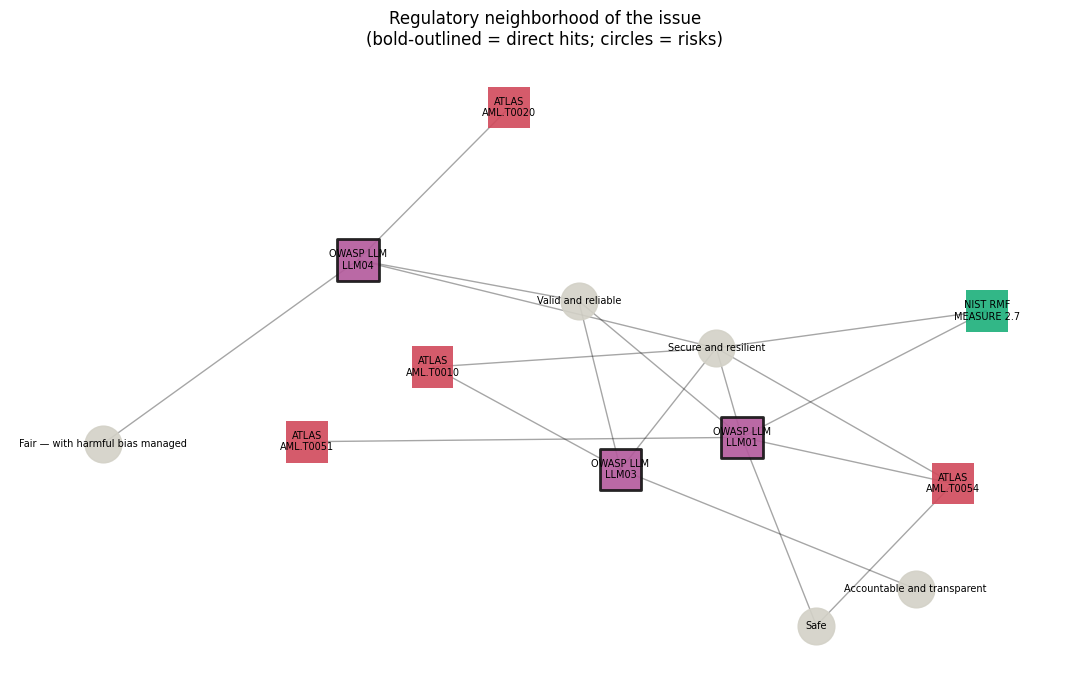

In [11]:
_ = reg.visualize(scenario, top_k=3)   # figure + reproducible description (needs matplotlib)

## 8. Coverage across scenarios

Run the whole categorized scenario set at once to see how well the corpus covers different governance themes \u2014 which frameworks and risk categories each scenario exercises. A quick way to spot gaps (a theme where too few frameworks or risks light up may need more crosswalks or provisions).

In [12]:
demo.coverage_report(reg)

,scenario,top provision,frameworks hit,risks identified,risk categories
0,Prohibited use — biometric surveillance,"EU AI Act, Article 5 — Prohibited AI practices",2,6,"Accountable and transparent, Fair — with harmf..."
1,Bias — credit underwriting,"NIST AI 600-1 (GenAI Profile), MS-2.11 — MEASU...",2,7,"Accountable and transparent, Explainable and i..."
2,Transparency — undisclosed chatbot,"EU AI Act, Article 14 — Human oversight",2,6,"Accountable and transparent, Fair — with harmf..."
3,Human oversight — automated decisions,"EU AI Act, Article 6 — Classification rules fo...",1,6,"Accountable and transparent, Fair — with harmf..."
4,Safety & robustness — unvalidated high-risk sy...,"MITRE ATLAS, AML.M0008 — Validate AI Model",1,3,"Privacy-enhanced, Secure and resilient, Valid ..."
5,Security — adversarial & prompt injection,"OWASP Top 10 for LLM (2025), LLM04 — Data and ...",1,5,"Accountable and transparent, Fair — with harmf..."
6,Privacy — personal data governance,"EU AI Act, Article 10 — Data and data governance",2,3,"Fair — with harmful bias managed, Privacy-enha..."
7,Record-keeping — no logging,"EU AI Act, Article 12 — Record-keeping",1,5,"Accountable and transparent, Privacy-enhanced,..."
8,Risk management — no process,"EU AI Act, Article 9 — Risk management system",1,5,"Accountable and transparent, Privacy-enhanced,..."
9,Post-market monitoring — none,"EU AI Act, Article 72 — Post-market monitoring...",1,5,"Accountable and transparent, Fair — with harmf..."


## What's next

- **Sharper retrieval** — set `RETRIEVER = 'embedding'` above for embedding-quality context.
- **Evidence paths** — return the full trail (issue → provision → crosswalk → provision) via GKN's path explainer.
- **Measure the claim** — benchmark the graph-grounded answer against a flat-RAG baseline.
- **Interface** — a "submit an issue" web UI.

**Extend Regulus:** add crosswalk rows or frameworks under `data/`, or swap the seed crosswalks for authoritative mappings.